# AP3 — Transformada z
**GELE7317 — Processamento de Sinais I** — Prof. Rafael S. Chaves  
**Alunos:** Isaque Soares, Guilherme Archanjo e Marcelo Auday

Resolução da Atividade Prática 3:
1. Resposta em frequência e diagrama de polos e zeros de $H_1(z)$;
2. Filtragem do sinal `handel.wav` e análise espectral;
3. Projeto do filtro inverso causal e estável $G_1(z) = 1/H_1(z)$;
4. Análise dos filtros pente $H_2(z) = \frac{1 - z^{-L}}{1 - a z^{-L}}$ para $a \in \{0{,}7; 0{,}9\}$ e $L \in \{1; 4; 10\}$;
5. Filtragem de áudio pelos sistemas pente;
6. Filtros inversos dos sistemas pente e diagnóstico de estabilidade marginal;
7. Aproximações FIR dos filtros inversos e relação entre a ordem $N$ e a qualidade (SNR).

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import freqz, lfilter, fftconvolve
from IPython.display import Audio, display

# Diretório dos arquivos de áudio (ajuste se necessário)
PASTA_DADOS = "dados"

In [17]:
def ler_wav(nome_arquivo):
    """Lê arquivo .wav da pasta local ou PASTA_DADOS e normaliza para [-1, 1]."""
    caminho = os.path.join(PASTA_DADOS, nome_arquivo)
    if not os.path.exists(caminho):
        caminho = nome_arquivo
    fs, x = wavfile.read(caminho)
    if x.ndim > 1:
        x = x[:, 0]
    if np.issubdtype(x.dtype, np.integer):
        x = x.astype(np.float64) / np.iinfo(x.dtype).max
    else:
        x = x.astype(np.float64)
    return fs, x

def tocar(x, fs):
    """Reproduz sinal de áudio inline no notebook."""
    display(Audio(x, rate=fs))

def calculate_spectrum(x, fs, titulo="Espectro", xlim=None, escala_db=True):
    """Calcula e exibe o espectro de magnitude via FFT de um sinal real."""
    n = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    mag = np.abs(X) / n

    plt.figure(figsize=(7, 3.2))
    if escala_db:
        plt.plot(freqs, 20 * np.log10(mag + 1e-12), linewidth=0.8, color="#1f77b4")
        plt.ylabel("Magnitude (dB)")
    else:
        plt.plot(freqs, mag, linewidth=0.8, color="#1f77b4")
        plt.ylabel("Magnitude")
    plt.xlabel("Frequência (Hz)")
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    if xlim is not None:
        plt.xlim(xlim)
    plt.tight_layout()
    plt.show()
    return freqs, mag

def plotar_polos_zeros(b, a, titulo="Diagrama de Polos e Zeros"):
    """Plota zeros (o) e polos (x) no plano complexo z com círculo unitário."""
    zeros = np.roots(b) if len(b) > 1 else np.array([])
    polos = np.roots(a) if len(a) > 1 else np.array([])

    theta = np.linspace(0, 2 * np.pi, 500)
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8, label="Círculo Unitário")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)

    if len(zeros) > 0:
        ax.scatter(zeros.real, zeros.imag, marker="o", facecolors="none",
                   edgecolors="#1f77b4", s=60, label=f"Zeros ({len(zeros)})", linewidths=1.5, zorder=3)
    if len(polos) > 0:
        ax.scatter(polos.real, polos.imag, marker="x", color="#d62728",
                   s=60, label=f"Polos ({len(polos)})", linewidths=1.5, zorder=3)

    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")
    ax.set_title(titulo)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return zeros, polos

def plotar_resposta_frequencia(b, a, titulo, fs=None, worN=2048):
    """Plota a magnitude em dB e a fase em radianos da função de transferência."""
    w, H = freqz(b, a, worN=worN, fs=fs if fs else 2 * np.pi)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True)
    ax1.plot(w, 20 * np.log10(np.abs(H) + 1e-12), color="#1f77b4", linewidth=0.9)
    ax1.set_ylabel("Magnitude (dB)")
    ax1.set_title(titulo)
    ax1.grid(True, alpha=0.3)

    ax2.plot(w, np.unwrap(np.angle(H)), color="#ff7f0e", linewidth=0.9)
    ax2.set_ylabel("Fase (rad)")
    ax2.set_xlabel("Frequência (Hz)" if fs else "Frequência normalizada (rad/amostra)")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return w, H

def avaliar_recuperacao(x_orig, x_rec, rotulo=""):
    """Calcula erro quadrático médio (MSE) e relação sinal-ruído (SNR)."""
    n = min(len(x_orig), len(x_rec))
    xo, xr = x_orig[:n], x_rec[:n]
    erro = xo - xr
    mse = np.mean(erro ** 2)
    snr_db = 10 * np.log10(np.mean(xo ** 2) / (mse + 1e-30))
    corr = np.corrcoef(xo, xr)[0, 1]
    print(f"{rotulo} -> MSE = {mse:.4e} | SNR = {snr_db:.2f} dB | Corr = {corr:.6f}")
    return mse, snr_db, corr

## Leitura do Áudio de Referência

In [18]:
fs_handel, x_handel = ler_wav("handel.wav")
print(f"handel.wav lido com sucesso: fs = {fs_handel} Hz, N = {len(x_handel)} amostras")

handel.wav lido com sucesso: fs = 8192 Hz, N = 73113 amostras


## Questão 1 — Resposta em frequência e diagrama de polos e zeros de $H_1(z)$

$$H_1(z) = 1 + 0{,}49 z^{-2} + 0{,}2401 z^{-6} - 0{,}0576 z^{-8} - 0{,}0282 z^{-10} - 0{,}0138 z^{-12}$$

Trata-se de um sistema FIR de 12ª ordem com $A(z) = 1$.

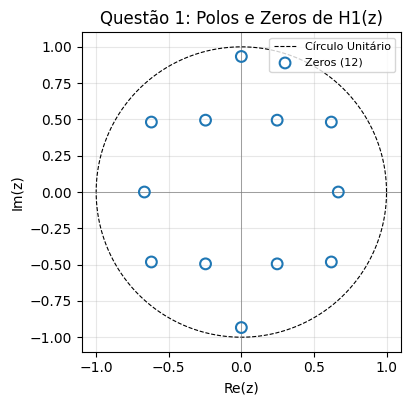

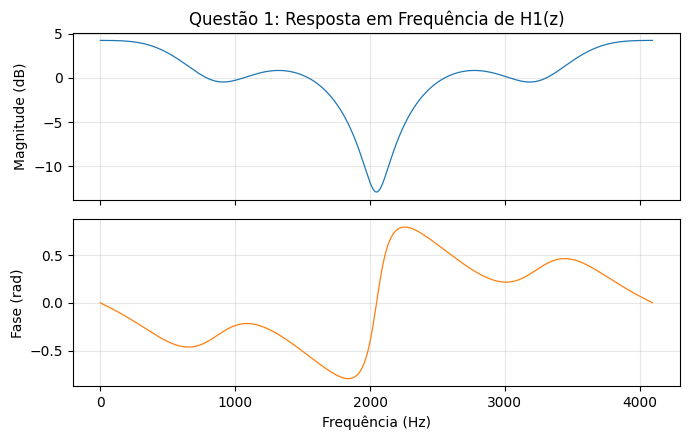

Módulo máximo entre os 12 zeros: 0.9336
Conclusão: O sistema é de FASE MÍNIMA (|z_k| < 1 para todas as raízes).


In [19]:
b1 = np.zeros(13)
b1[0] = 1.0
b1[2] = 0.49
b1[6] = 0.2401
b1[8] = -0.0576
b1[10] = -0.0282
b1[12] = -0.0138
a1 = np.array([1.0])

zeros_q1, polos_q1 = plotar_polos_zeros(b1, a1, "Questão 1: Polos e Zeros de H1(z)")
plotar_resposta_frequencia(b1, a1, "Questão 1: Resposta em Frequência de H1(z)", fs=fs_handel)

r_max = np.max(np.abs(zeros_q1))
print(f"Módulo máximo entre os 12 zeros: {r_max:.4f}")
if r_max < 1.0:
    print("Conclusão: O sistema é de FASE MÍNIMA (|z_k| < 1 para todas as raízes).")
else:
    print("Conclusão: O sistema NÃO é de fase mínima.")

## Questão 2 — Filtragem de `handel.wav` por $H_1(z)$ e Espectro

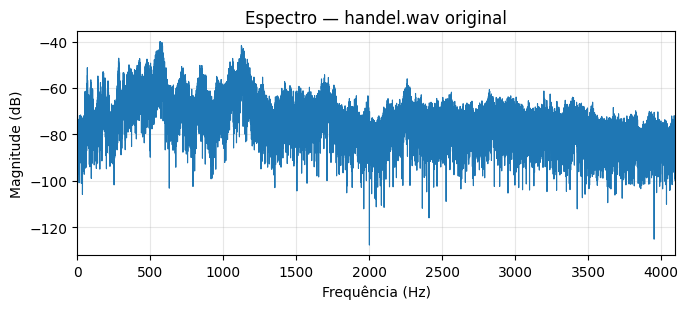

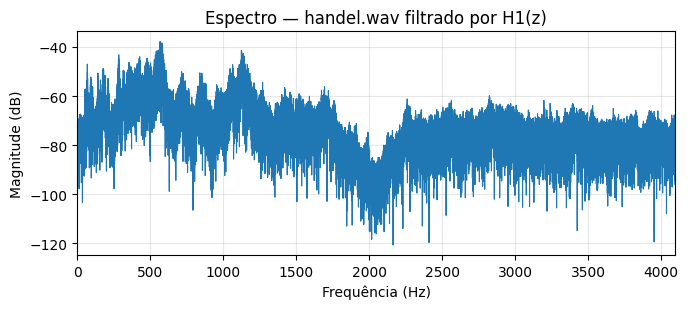

Áudio Original:


Áudio Filtrado por H1(z):


In [20]:
y1 = lfilter(b1, a1, x_handel)

calculate_spectrum(x_handel, fs_handel, titulo="Espectro — handel.wav original", xlim=(0, fs_handel / 2))
calculate_spectrum(y1, fs_handel, titulo="Espectro — handel.wav filtrado por H1(z)", xlim=(0, fs_handel / 2))

print("Áudio Original:")
tocar(x_handel, fs_handel)
print("Áudio Filtrado por H1(z):")
tocar(y1, fs_handel)

## Questão 3 — Projeto do Filtro Inverso e Recuperação

Como todos os zeros de $H_1(z)$ possuem raio inferior a 0,8415 (fase mínima), o filtro inverso ideal:
$$G_1(z) = \frac{1}{H_1(z)}$$
tem todos os seus polos estritamente no interior do círculo unitário, sendo um **filtro IIR causal e BIBO-estável**.

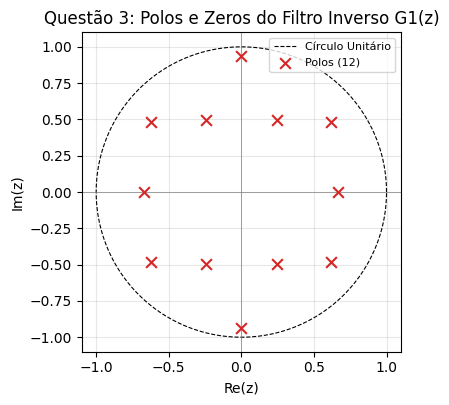

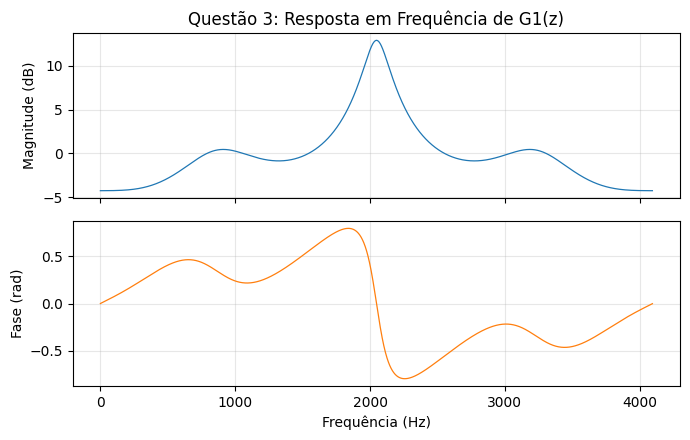

Questão 3: Recuperação Direta IIR -> MSE = 4.8438e-34 | SNR = 285.85 dB | Corr = 1.000000


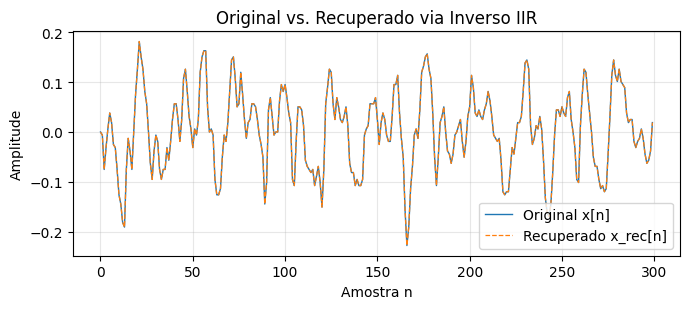

Áudio Recuperado:


In [21]:
b_inv1 = np.array([1.0])
a_inv1 = b1.copy()

plotar_polos_zeros(b_inv1, a_inv1, "Questão 3: Polos e Zeros do Filtro Inverso G1(z)")
plotar_resposta_frequencia(b_inv1, a_inv1, "Questão 3: Resposta em Frequência de G1(z)", fs=fs_handel)

# Recuperação no domínio do tempo via equação a diferenças causal (lfilter)
x_rec1 = lfilter(b_inv1, a_inv1, y1)
avaliar_recuperacao(x_handel, x_rec1, rotulo="Questão 3: Recuperação Direta IIR")

# Comparação temporal das primeiras 300 amostras
plt.figure(figsize=(7, 3.2))
plt.plot(x_handel[:300], label="Original x[n]", linewidth=1.0)
plt.plot(x_rec1[:300], "--", label="Recuperado x_rec[n]", linewidth=0.9, color="tab:orange")
plt.xlabel("Amostra n")
plt.ylabel("Amplitude")
plt.title("Original vs. Recuperado via Inverso IIR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Áudio Recuperado:")
tocar(x_rec1, fs_handel)

## Questão 4 — Filtros Pente (Comb Filters) $H_2(z) = \frac{1 - z^{-L}}{1 - a z^{-L}}$

Para $a \in \{0{,}7; 0{,}9\}$ e $L \in \{1; 4; 10\}$.

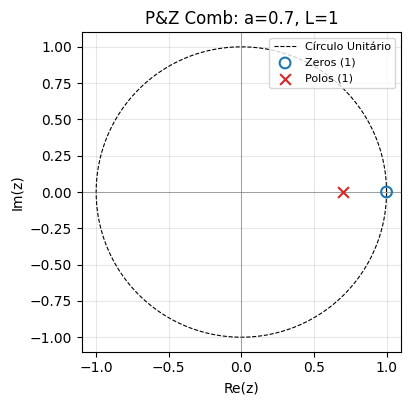

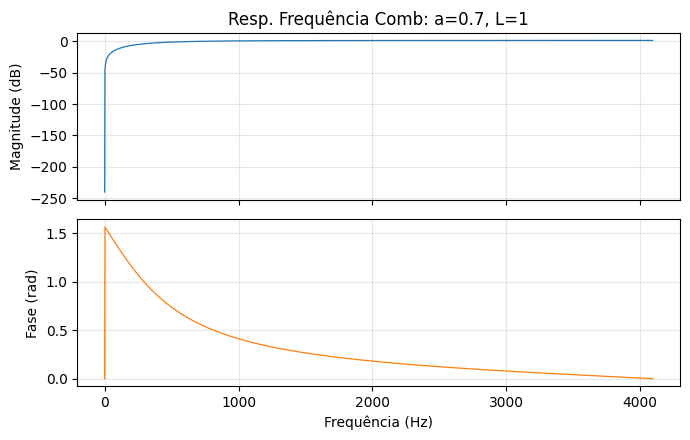

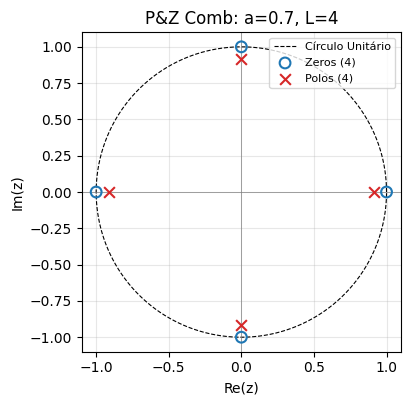

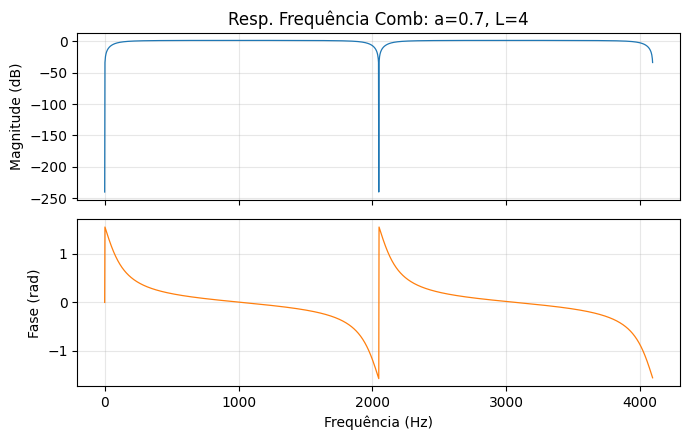

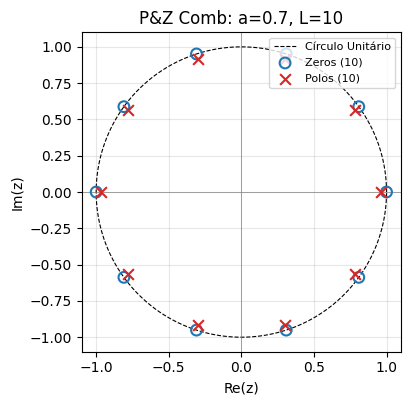

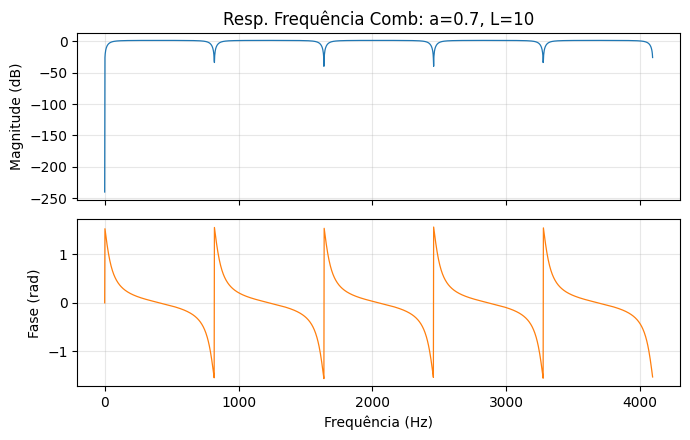

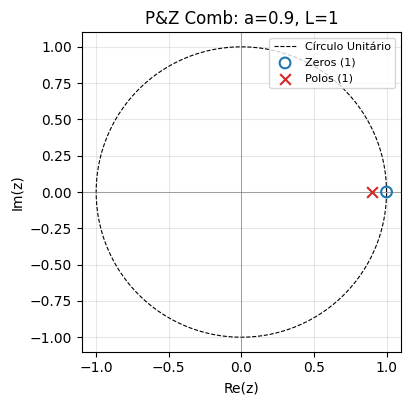

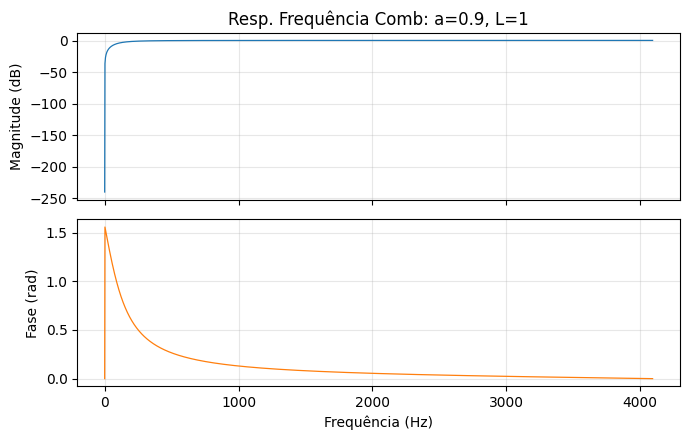

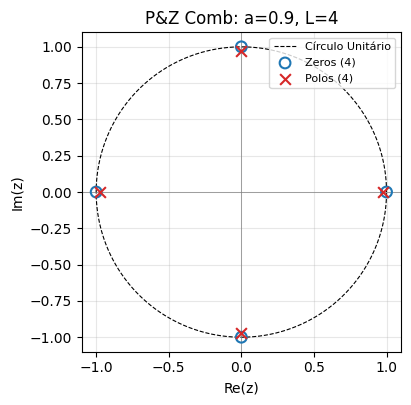

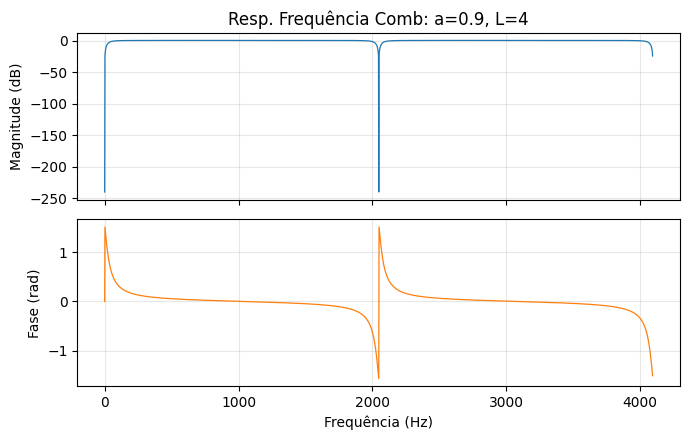

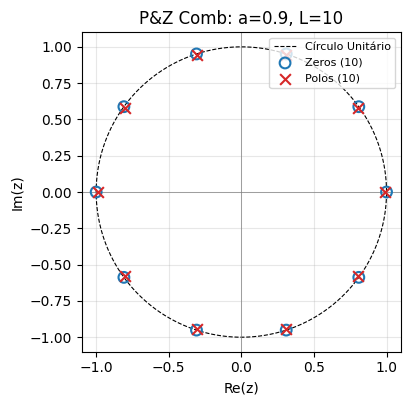

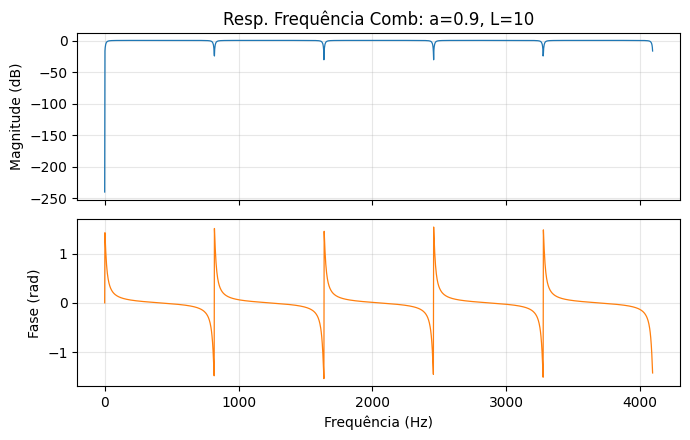

In [22]:
def construir_comb(a_val, L_val):
    b = np.zeros(L_val + 1)
    b[0] = 1.0
    b[-1] = -1.0
    a = np.zeros(L_val + 1)
    a[0] = 1.0
    a[-1] = -a_val
    return b, a

valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

sistemas_comb = {}
for a_val in valores_a:
    for L_val in valores_L:
        chave = f"a={a_val}, L={L_val}"
        sistemas_comb[chave] = construir_comb(a_val, L_val)

for chave, (b_c, a_c) in sistemas_comb.items():
    plotar_polos_zeros(b_c, a_c, f"P&Z Comb: {chave}")
    plotar_resposta_frequencia(b_c, a_c, f"Resp. Frequência Comb: {chave}", fs=fs_handel)

## Questão 5 — Filtragem de `handel.wav` pelos Filtros Pente

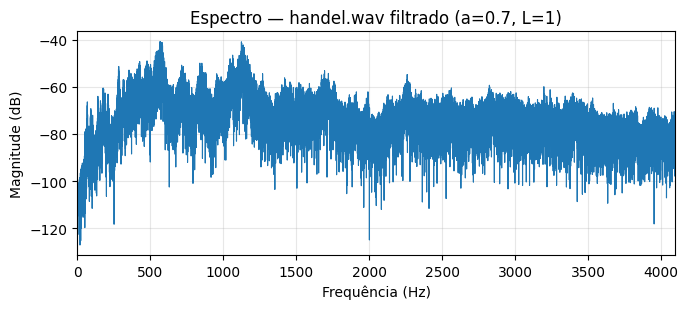

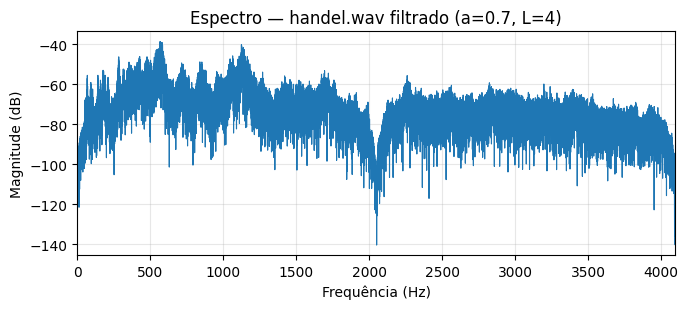

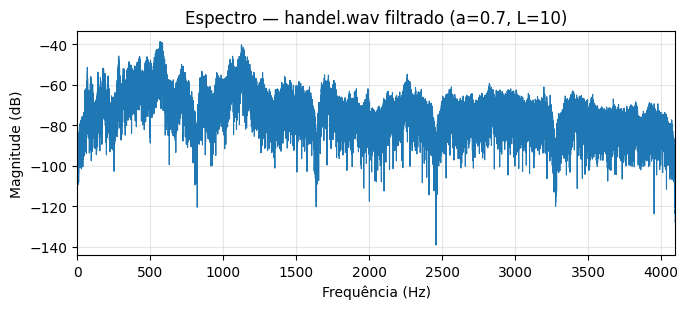

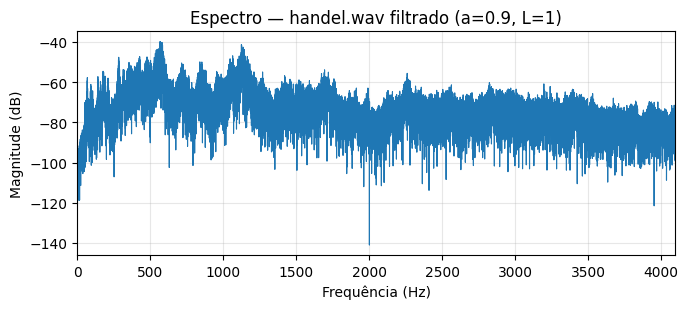

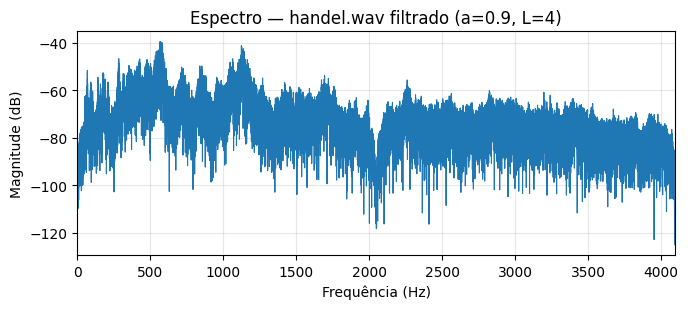

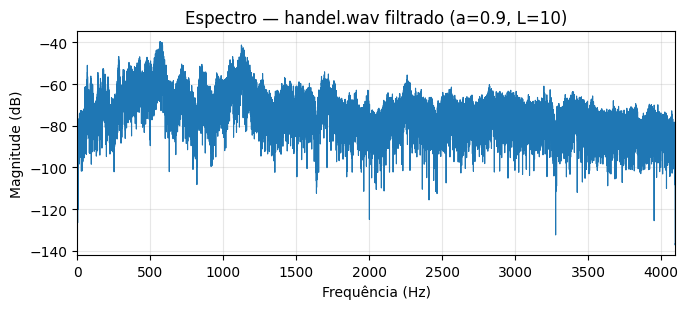

Áudio filtrado (a=0.7, L=1):


Áudio filtrado (a=0.7, L=4):


Áudio filtrado (a=0.7, L=10):


Áudio filtrado (a=0.9, L=1):


Áudio filtrado (a=0.9, L=4):


Áudio filtrado (a=0.9, L=10):


In [23]:
respostas_comb = {}
for chave, (b_c, a_c) in sistemas_comb.items():
    y_c = lfilter(b_c, a_c, x_handel)
    respostas_comb[chave] = y_c
    calculate_spectrum(y_c, fs_handel, titulo=f"Espectro — handel.wav filtrado ({chave})", xlim=(0, fs_handel / 2))

for chave, y_c in respostas_comb.items():
    print(f"Áudio filtrado ({chave}):")
    tocar(y_c, fs_handel)

## Questão 6 — Filtros Inversos dos Sistemas Pente

O inverso exato é:
$$G_2(z) = \frac{1 - a z^{-L}}{1 - z^{-L}}$$
Os polos de $G_2(z)$ localizam-se em $p_k = e^{j 2\pi k / L}$ ($|p_k| = 1$), tornando o sistema **marginalmente estável**.

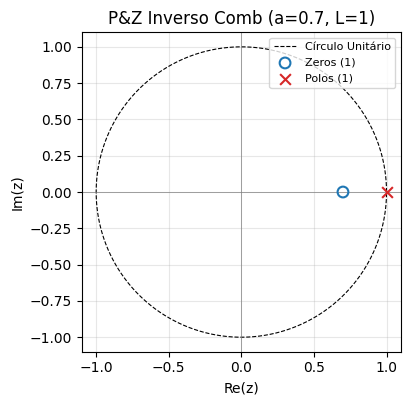

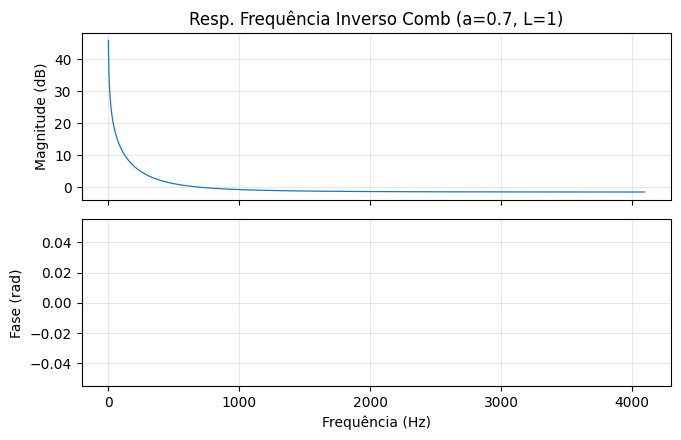

Inverso Comb (a=0.7, L=1) -> MSE = 5.9332e-30 | SNR = 277.45 dB | Corr = 1.000000


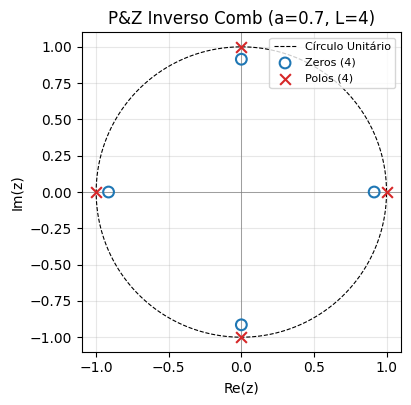

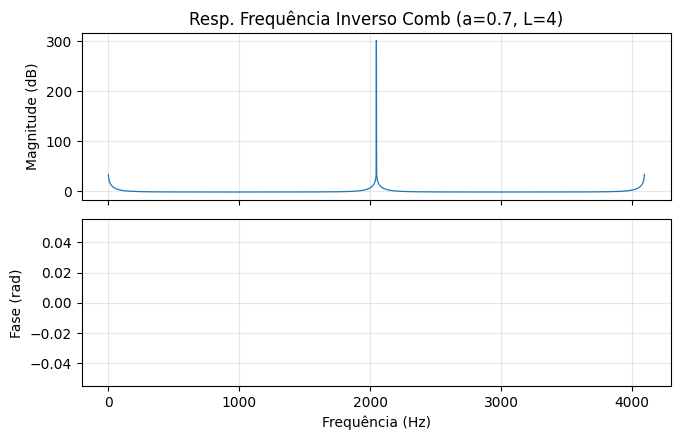

Inverso Comb (a=0.7, L=4) -> MSE = 1.3503e-30 | SNR = 282.14 dB | Corr = 1.000000


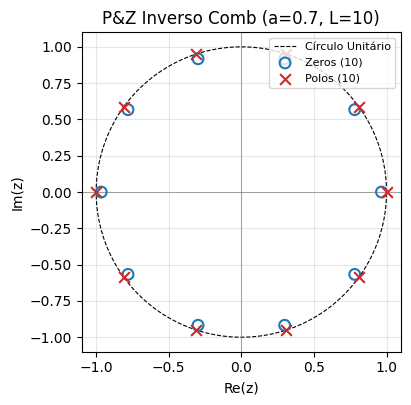

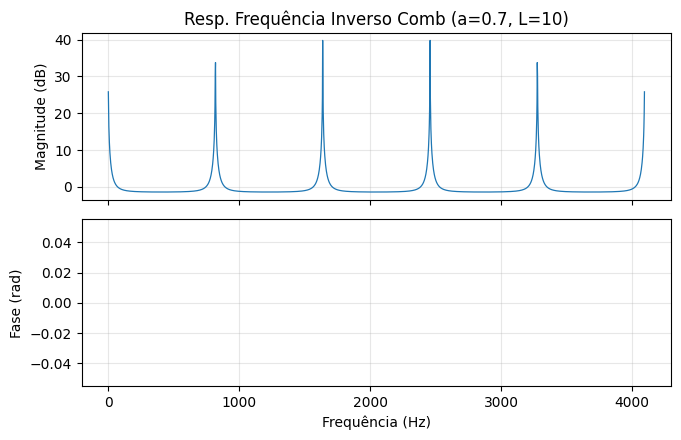

Inverso Comb (a=0.7, L=10) -> MSE = 7.9315e-31 | SNR = 283.32 dB | Corr = 1.000000


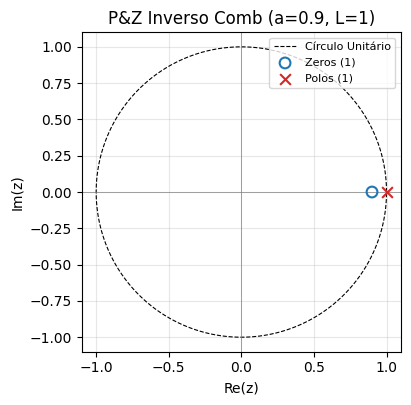

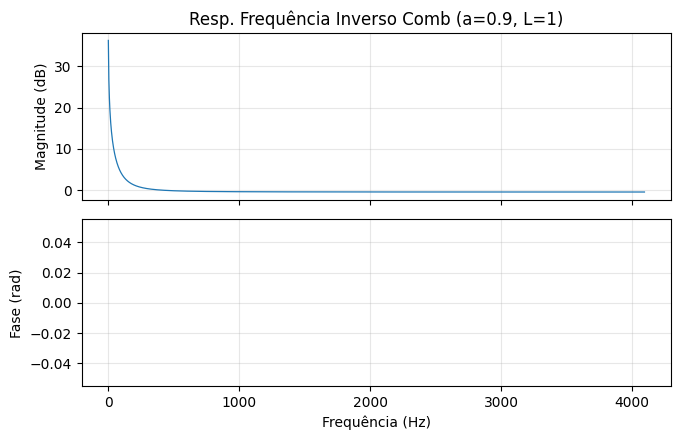

Inverso Comb (a=0.9, L=1) -> MSE = 1.2723e-29 | SNR = 274.48 dB | Corr = 1.000000


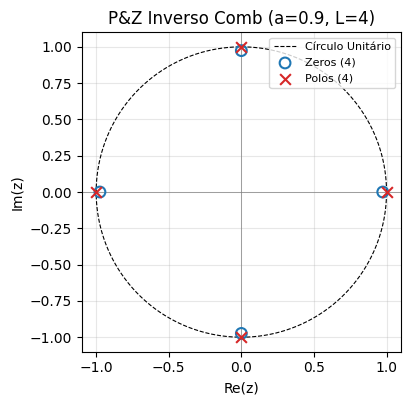

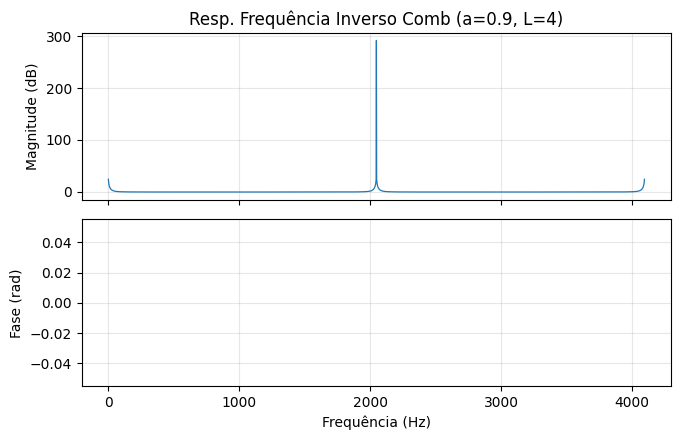

Inverso Comb (a=0.9, L=4) -> MSE = 5.0025e-31 | SNR = 284.09 dB | Corr = 1.000000


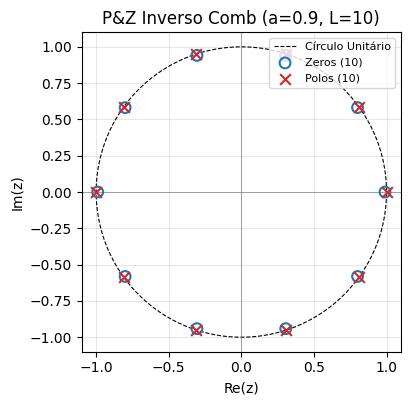

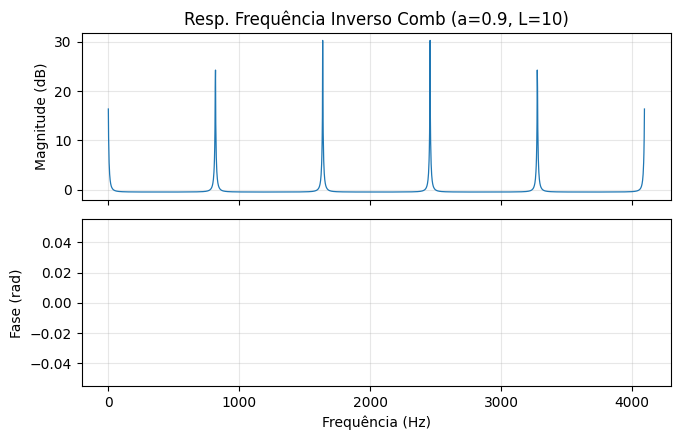

Inverso Comb (a=0.9, L=10) -> MSE = 5.6511e-31 | SNR = 283.91 dB | Corr = 1.000000
Áudio recuperado (a=0.7, L=1):


Áudio recuperado (a=0.7, L=4):


Áudio recuperado (a=0.7, L=10):


Áudio recuperado (a=0.9, L=1):


Áudio recuperado (a=0.9, L=4):


Áudio recuperado (a=0.9, L=10):


In [24]:
recuperados_comb = {}

for chave, (b_c, a_c) in sistemas_comb.items():
    b_inv_c = a_c.copy()
    a_inv_c = b_c.copy()

    plotar_polos_zeros(b_inv_c, a_inv_c, f"P&Z Inverso Comb ({chave})")
    plotar_resposta_frequencia(b_inv_c, a_inv_c, f"Resp. Frequência Inverso Comb ({chave})", fs=fs_handel)

    # Tentativa de reconstrução direta
    y_c = respostas_comb[chave]
    x_rec_c = lfilter(b_inv_c, a_inv_c, y_c)
    recuperados_comb[chave] = x_rec_c
    avaliar_recuperacao(x_handel, x_rec_c, rotulo=f"Inverso Comb ({chave})")

for chave, x_rec_c in recuperados_comb.items():
    print(f"Áudio recuperado ({chave}):")
    tocar(x_rec_c, fs_handel)

## Questão 7 — Aproximações FIR dos Filtros Inversos

Aproximação de ordem $N$ por truncamento da resposta ao impulso dos filtros inversos:
1. **Inverso de $H_1(z)$ (Q3 — Fase Mínima):** cauda exponencialmente decrescente $\implies$ SNR cresce linearmente em escala logarítmica;
2. **Inverso do Comb (Q6 — Polos sobre $|z|=1$):** pulsos constantes de ganho $1-a$ $\implies$ resposta não decresce, deixando ecos persistentes.

In [25]:
ORDENS_FIR = [16, 32, 64, 128, 256, 512, 1024]

def obter_fir_truncado(b_i, a_i, N):
    imp = np.zeros(N)
    imp[0] = 1.0
    return lfilter(b_i, a_i, imp)

# 1. Teste para o inverso da Questão 3
snrs_fir_q3 = []
print("--- APROXIMAÇÃO FIR: INVERSO Q3 (Fase Mínima) ---")
for N in ORDENS_FIR:
    h_fir_q3 = obter_fir_truncado(b_inv1, a_inv1, N)
    x_rec_fir = fftconvolve(y1, h_fir_q3, mode="full")[:len(x_handel)]
    _, snr_val, _ = avaliar_recuperacao(x_handel, x_rec_fir, rotulo=f"Q3 FIR N={N:4d}")
    snrs_fir_q3.append(snr_val)

# 2. Teste para o inverso da Questão 6 (a=0.7, L=4)
chave_ex = "a=0.7, L=4"
b_c_ex, a_c_ex = sistemas_comb[chave_ex]
y_c_ex = respostas_comb[chave_ex]

snrs_fir_q6 = []
print(f"\n--- APROXIMAÇÃO FIR: INVERSO Q6 ({chave_ex}) ---")
for N in ORDENS_FIR:
    h_fir_q6 = obter_fir_truncado(a_c_ex, b_c_ex, N)
    x_rec_fir_c = fftconvolve(y_c_ex, h_fir_q6, mode="full")[:len(x_handel)]
    _, snr_val_c, _ = avaliar_recuperacao(x_handel, x_rec_fir_c, rotulo=f"Q6 Comb FIR N={N:4d}")
    snrs_fir_q6.append(snr_val_c)

--- APROXIMAÇÃO FIR: INVERSO Q3 (Fase Mínima) ---
Q3 FIR N=  16 -> MSE = 8.3729e-04 | SNR = 16.63 dB | Corr = 0.989921
Q3 FIR N=  32 -> MSE = 9.0750e-05 | SNR = 26.28 dB | Corr = 0.998827
Q3 FIR N=  64 -> MSE = 1.1252e-06 | SNR = 45.34 dB | Corr = 0.999986
Q3 FIR N= 128 -> MSE = 1.7042e-10 | SNR = 83.54 dB | Corr = 1.000000
Q3 FIR N= 256 -> MSE = 3.9103e-18 | SNR = 159.93 dB | Corr = 1.000000
Q3 FIR N= 512 -> MSE = 1.8238e-32 | SNR = 285.78 dB | Corr = 1.000000
Q3 FIR N=1024 -> MSE = 1.6670e-32 | SNR = 285.78 dB | Corr = 1.000000

--- APROXIMAÇÃO FIR: INVERSO Q6 (a=0.7, L=4) ---
Q6 Comb FIR N=  16 -> MSE = 2.5134e-03 | SNR = 11.85 dB | Corr = 0.966901
Q6 Comb FIR N=  32 -> MSE = 2.5130e-03 | SNR = 11.85 dB | Corr = 0.972293
Q6 Comb FIR N=  64 -> MSE = 2.5124e-03 | SNR = 11.85 dB | Corr = 0.973262
Q6 Comb FIR N= 128 -> MSE = 2.5110e-03 | SNR = 11.86 dB | Corr = 0.968578
Q6 Comb FIR N= 256 -> MSE = 2.5083e-03 | SNR = 11.86 dB | Corr = 0.968165
Q6 Comb FIR N= 512 -> MSE = 2.5021e-03 | SNR

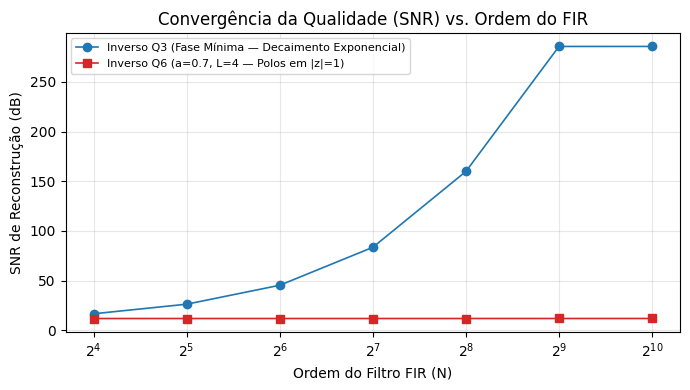

In [26]:
# Comparação gráfica: SNR vs Ordem N
plt.figure(figsize=(7, 4))
plt.plot(ORDENS_FIR, snrs_fir_q3, "o-", linewidth=1.2, label="Inverso Q3 (Fase Mínima — Decaimento Exponencial)", color="#1f77b4")
plt.plot(ORDENS_FIR, snrs_fir_q6, "s-", linewidth=1.2, label=f"Inverso Q6 ({chave_ex} — Polos em |z|=1)", color="#d62728")
plt.xscale("log", base=2)
plt.xlabel("Ordem do Filtro FIR (N)")
plt.ylabel("SNR de Reconstrução (dB)")
plt.title("Convergência da Qualidade (SNR) vs. Ordem do FIR")
plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [27]:
# Reprodução do áudio reconstruído via FIR de ordem 512
h_fir_q3_best = obter_fir_truncado(b_inv1, a_inv1, 512)
x_rec_q3_fir = fftconvolve(y1, h_fir_q3_best, mode="full")[:len(x_handel)]
print("Áudio Recuperado via FIR N=512 (Questão 3):")
tocar(x_rec_q3_fir, fs_handel)

h_fir_q6_best = obter_fir_truncado(a_c_ex, b_c_ex, 512)
x_rec_q6_fir = fftconvolve(y_c_ex, h_fir_q6_best, mode="full")[:len(x_handel)]
print(f"Áudio Recuperado via FIR N=512 (Questão 6 — {chave_ex}):")
tocar(x_rec_q6_fir, fs_handel)

Áudio Recuperado via FIR N=512 (Questão 3):


Áudio Recuperado via FIR N=512 (Questão 6 — a=0.7, L=4):
